# Churn Bank Customer Project

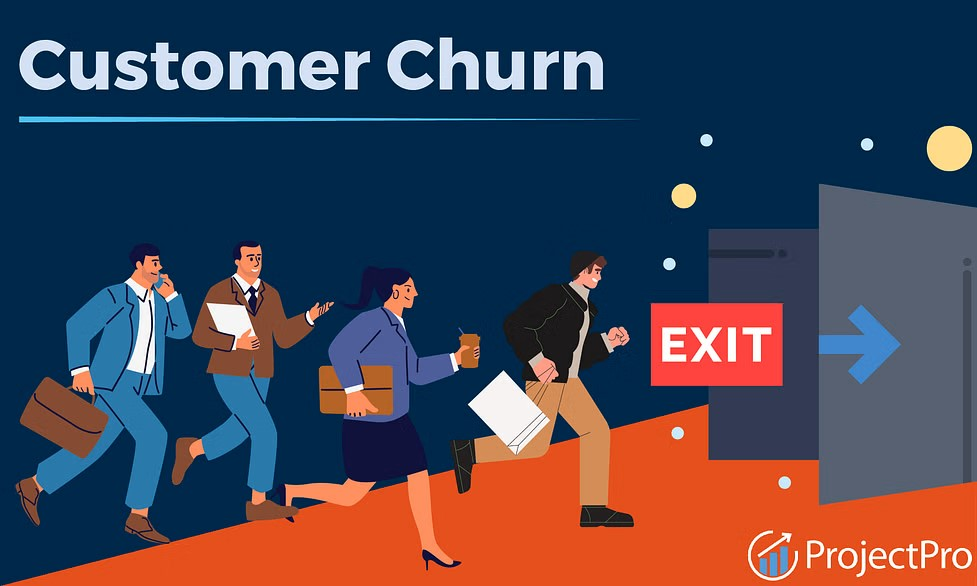

<a id="cont"></a>

## Table of Contents

<a href=#one>1. Introduction</a>

<a href=#two>2. Importing Packages</a>

<a href=#three>3. Loading Data</a>

<a href=#four>4. Exploratory Data Analysis (EDA)</a>

<a href=#five>5. Data Preprocessing & Feature Engineering</a>

<a href=#six>6. Modelling</a>

<a href=#seven>7. Model Evaluation</a>

<a href=#seven>8. Conclusion & Business Recommandation</a>


<a id="one"></a>
### 1. Introduction
<a href=#cont>Back to Table of Contents</a>

Customer churn is the phenomenon where customers stop doing business with a company. It is one of the most costly challenges in the banking industry. Acquiring a new customer costs 5 to 7 times more than retaining an existing one, making churn prevention a top strategic priority.

This project focuses on a European retail bank that has observed a significant portion of its customer base closing accounts or disengaging over the past year. The bank has historical data on 10,000 customers, including demographics, account details, and behavioural patterns.

### Problem Statement

##### Can we accurately predict which customers are likely to churn, so the bank can intervene proactively and reduce attrition?

### Objective

1. Perform exploratory analysis to understand the profile of churning customers
2. Engineer meaningful features that capture customer behaviour
3. Build and compare different models
4. Identify the top drivers of churn
5. Provide actionable business recommendations based on the findings





 <a id="two"></a>
### 2. Importing Packages
<a href=#cont>Back to Table of Contents</a>

In [5]:
# Import libraries

# Main libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
colors = {'Stay': '#2ecc71', 'Churn': '#e74c3c'}

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score
)


<a id="three"></a>
### 3. Loading the Data
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

In [6]:
#Loading the data and display first 5 rows.
churn = pd.read_csv("C:/Users/sabel/Downloads/Churn_Modelling1.csv")
churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
churn.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [8]:
# Data types
print('=== Data Info ===')
churn.info()

# Missing values
print('\n=== Missing Values ===')
print(churn.isnull().sum())

# Duplicates
print('\n=== Duplicate Rows ===')
print(churn.duplicated().sum())

# Shape of Dataset
print('\n=== Shape ===')
print(churn.shape)

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

=== Missing Values ===
RowNumber          0
CustomerId         0
Surname   

In [9]:
# Descriptive Statistics
churn.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


#### Initial Observation:
- There are 10,000 rows and 14 columns 
- There no missing values or duplicates
- RowNumber, CustomerId, and Surname are identifiers with no predictive value
- Geography and Gender are categorical features that need encoding
- Exited is our binary target variable (1 = churned, 0 = stayed)

<a id="four"></a>
### 4. Exploratory Data Analysis (EDA)
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

#### 4.1 Target Value Distribution

Churned customers : 2,037 (20.4%)
Retained customers: 7,963 (79.6%)


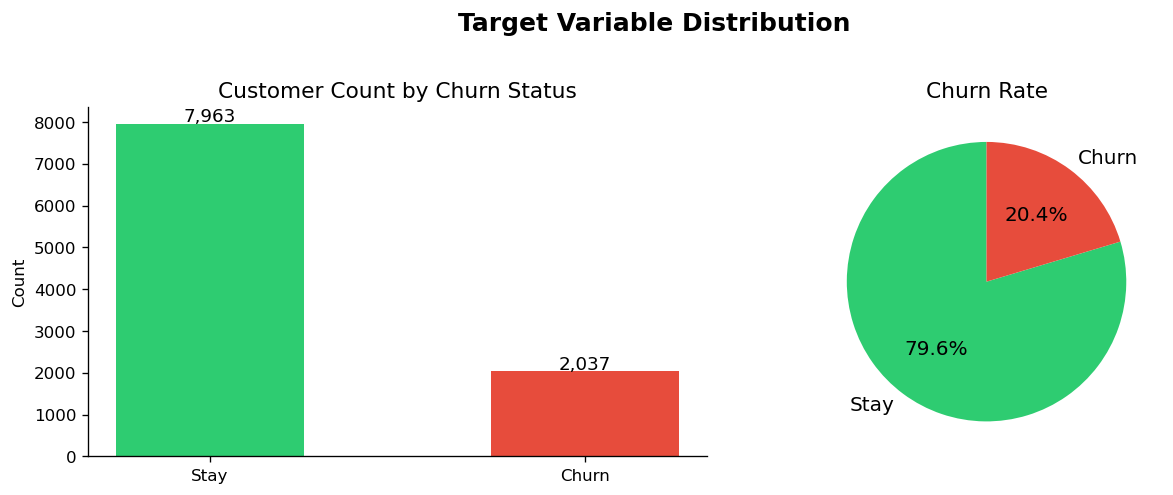


 Class imbalance detected: 20.4% churn rate.
 We will account for this during modelling and use ROC-AUC & F1 as primary metrics.


In [12]:
churn_counts = churn['Exited'].value_counts()
churn_rate = churn['Exited'].mean()

print(f'Churned customers : {churn_counts[1]:,} ({churn_rate:.1%})')
print(f'Retained customers: {churn_counts[0]:,} ({1-churn_rate:.1%})')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
bars = axes[0].bar(['Stay', 'Churn'], churn_counts.values,
                   color=[colors['Stay'], colors['Churn']], width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=11)
axes[0].set_title('Customer Count by Churn Status', fontsize=13)
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie([churn_counts[0], churn_counts[1]],
            labels=['Stay', 'Churn'],
            colors=[colors['Stay'], colors['Churn']],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Churn Rate', fontsize=13)

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Class imbalance detected: {churn_rate:.1%} churn rate.')
print(' We will account for this during modelling and use ROC-AUC & F1 as primary metrics.')

#### 4.2 Churn Rate by Categorical Feature

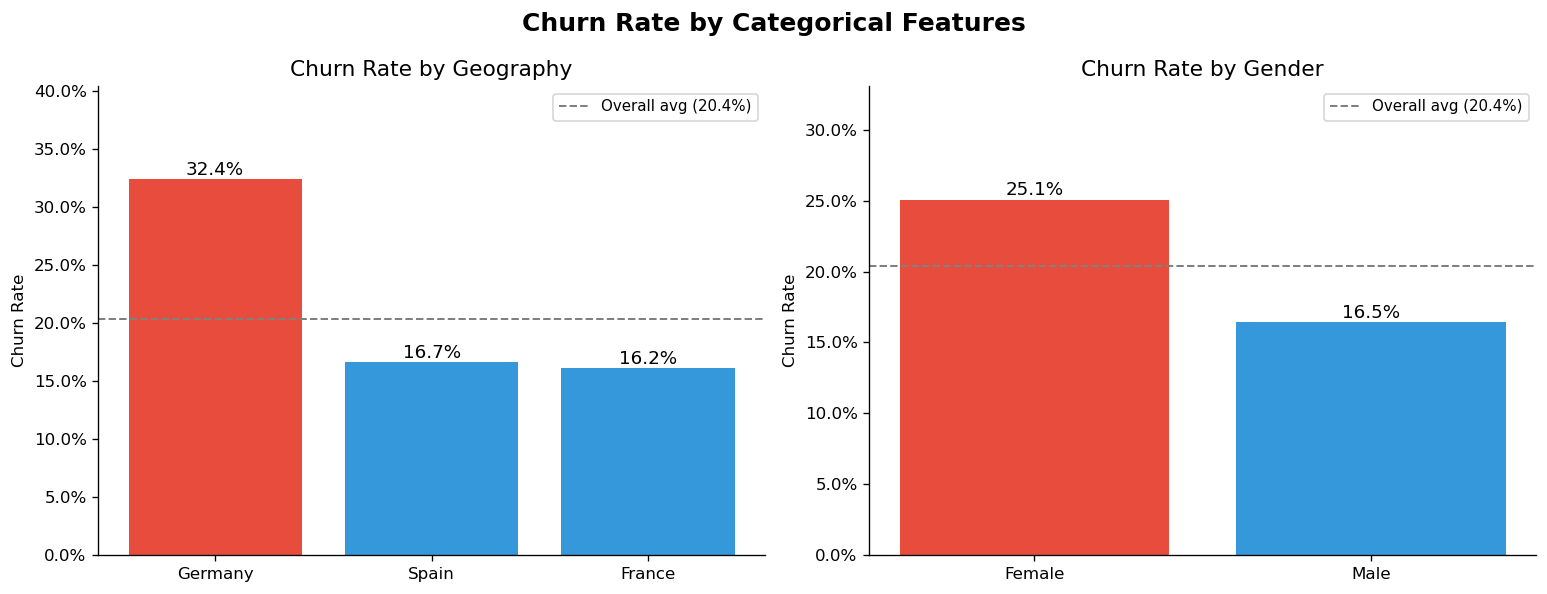

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['Geography', 'Gender']):
    churn_by_cat = churn.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(churn_by_cat.index, churn_by_cat.values,
                  color=[colors['Churn'] if v > 20 else '#3498db' for v in churn_by_cat.values])
    ax.axhline(churn_rate * 100, color='grey', linestyle='--', linewidth=1.2, label=f'Overall avg ({churn_rate:.1%})')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, churn_by_cat.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=11)
    ax.set_title(f'Churn Rate by {col}', fontsize=13)
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, max(churn_by_cat.values) + 8)
    ax.legend(fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Insight:
- Germany has churn rate of 32% nearly double Spain(16.7%) and France(16.2%)
- Germany churn rate is above overall average
- Spain and France churn rate are closer to overall average
- Female churn at 25%, compared to 17% for Male
- Female churn rate is above overall average
- Male churn rate is closer to overall average 

#### 4.3 Numerical Features by Churn Status

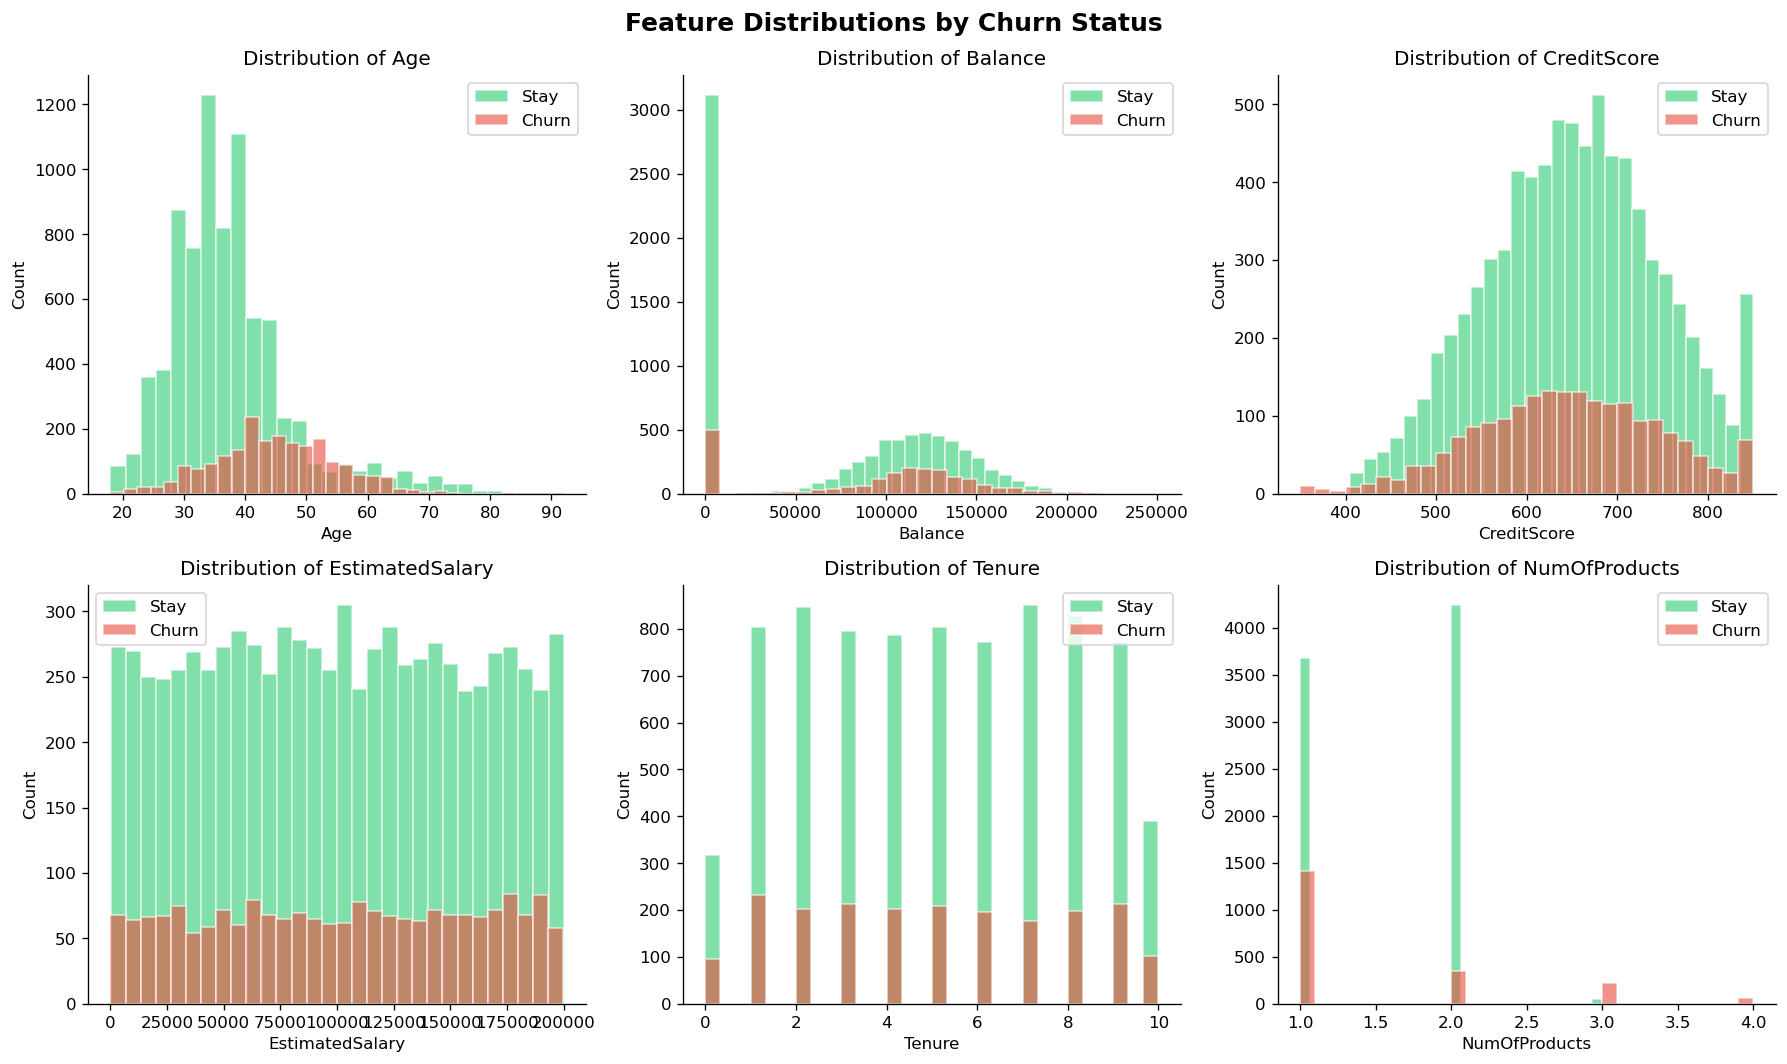

In [15]:
num_cols = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
churn['Churn Label'] = churn['Exited'].map({0: 'Stay', 1: 'Churn'})

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in colors.items():
        subset = churn[churn['Churn Label'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions by Churn Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Insight:
- **Insights:**
- **Age**: Churners are notably older. The churn distribution is right-skewed relative to stayers
- **Balance**: Customers with a zero balance are significantly less likely to churn; high-balance customers churn more
- **NumOfProducts**: Customers with 3-4 products churn at extremely high rates (product overload signal)
- **CreditScore, Tenure, EstimatedSalary**: Minimal difference between churners and stayers

#### 4.4 Churn Rate by Active Membership & Number of Products

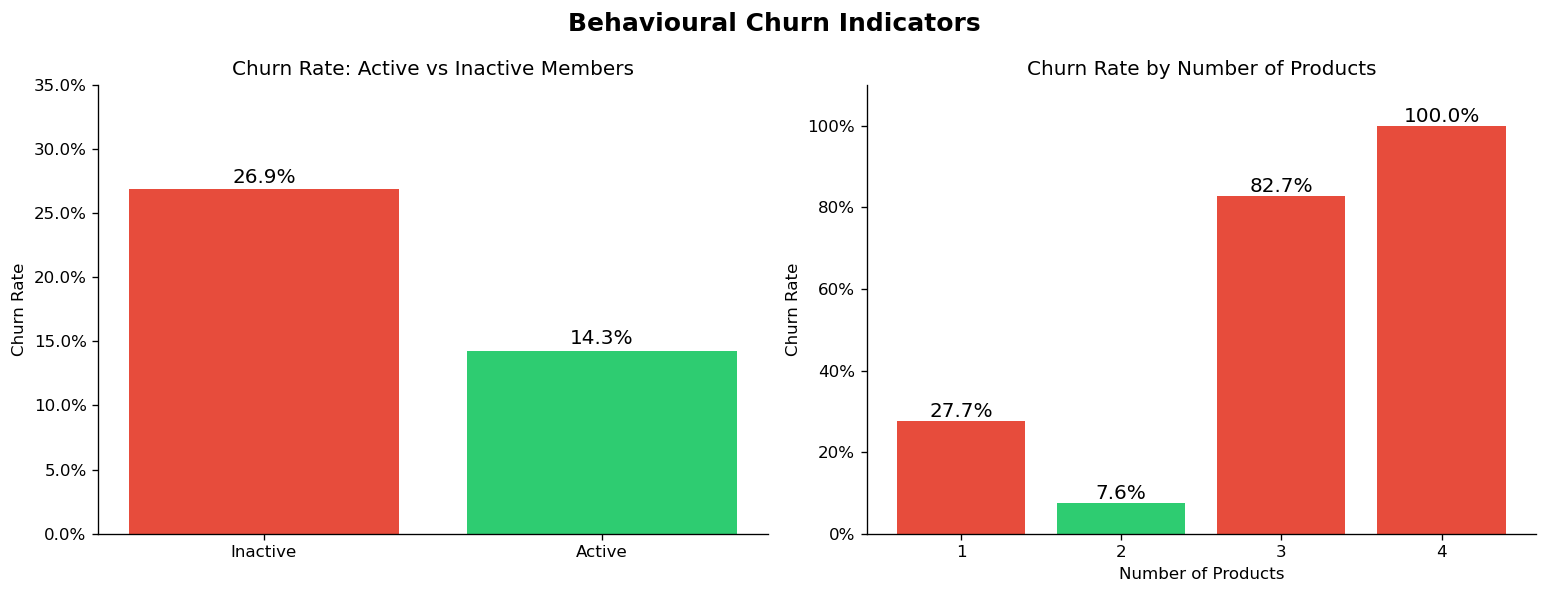

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Active member
active_churn = churn.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.index = ['Inactive', 'Active']
axes[0].bar(active_churn.index, active_churn.values,
            color=[colors['Churn'], colors['Stay']])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(active_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)
axes[0].set_title('Churn Rate: Active vs Inactive Members', fontsize=12)
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 35)

# Number of products
prod_churn = churn.groupby('NumOfProducts')['Exited'].mean() * 100
colors = [colors['Churn'] if v > 20 else colors['Stay'] for v in prod_churn.values]
axes[1].bar(prod_churn.index.astype(str), prod_churn.values, color=colors)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(prod_churn.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12)
axes[1].set_title('Churn Rate by Number of Products', fontsize=12)
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 110)

plt.suptitle('Behavioural Churn Indicators', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#### Insight:
- Inactive members churn at 27% almost double Active members(14%)
- Customers with 3 or 4 products churn at extremely high rates (>80%)

#### 4.5 Correlation Matrix

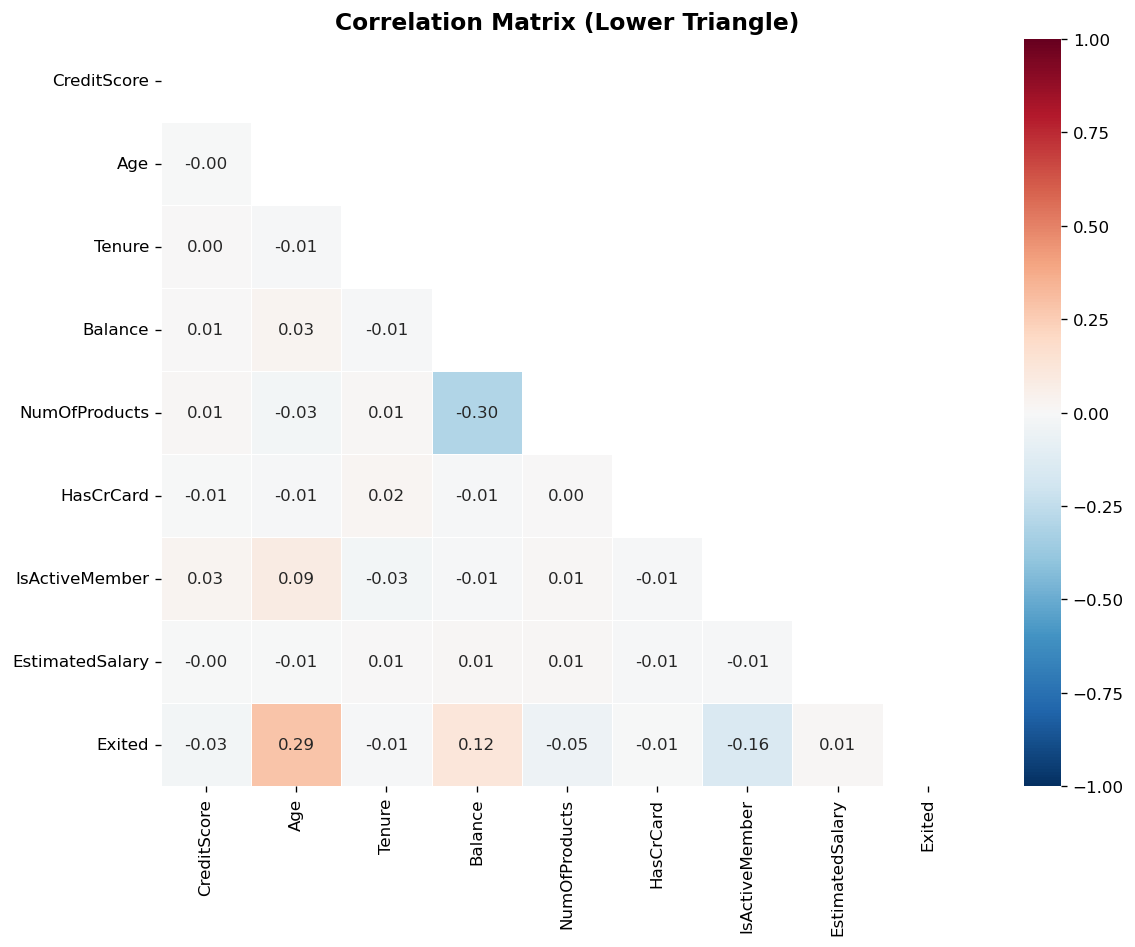

Top correlations with Exited (churn):
Age                0.285323
IsActiveMember    -0.156128
Balance            0.118533
NumOfProducts     -0.047820
CreditScore       -0.027094
Tenure            -0.014001
EstimatedSalary    0.012097
HasCrCard         -0.007138


In [17]:
corr = churn.drop(columns=['RowNumber', 'CustomerId', 'Churn Label']).corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with Exited (churn):')
print(corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False).to_string())

<a id="five"></a>
### 5. Data Preprocessong & Feature Engineering
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>


#### 5.1 Feature Engineering

In [24]:
churn_model = churn.copy()

# 1. Balance-to-Salary ratio: captures relative wealth exposure
churn_model['BalanceToSalary'] = churn_model['Balance'] / (churn_model['EstimatedSalary'] + 1)

# 2. Has Balance flag: customers with zero balance behave differently
churn_model['HasBalance'] = (churn_model['Balance'] > 0).astype(int)

# 3. High-Value Inactive: high-balance customers who are not active (high risk)
balance_median = churn_model['Balance'].median()
churn_model['HighValueInactive'] = (
    (churn_model['Balance'] > balance_median) & (churn_model['IsActiveMember'] == 0)
).astype(int)

# 4. Age group: capture non-linear age effects
churn_model['AgeGroup'] = pd.cut(churn_model['Age'], bins=[0, 30, 45, 60, 100],
                               labels=['Young', 'MiddleAge', 'Senior', 'Elderly'])

# 5. Products overloaded flag: 3+ products churn at extreme rates
churn_model['ProductsOverloaded'] = (churn_model['NumOfProducts'] >= 3).astype(int)

print('New features added:')
new_features = ['BalanceToSalary', 'HasBalance', 'HighValueInactive', 'AgeGroup', 'ProductsOverloaded']
print(churn_model[new_features].head())

New features added:
   BalanceToSalary  HasBalance  HighValueInactive   AgeGroup  \
0         0.000000           0                  0  MiddleAge   
1         0.744670           1                  0  MiddleAge   
2         1.401362           1                  1  MiddleAge   
3         0.000000           0                  0  MiddleAge   
4         1.587035           1                  0  MiddleAge   

   ProductsOverloaded  
0                   0  
1                   0  
2                   1  
3                   0  
4                   0  


#### 5.2 Define Features & Target

In [25]:
# Drop unneeded columns and define 
drop_cols = ['RowNumber', 'CustomerId', 'Surname', 'Exited', 'Churn Label']
X = churn_model.drop(columns=drop_cols)
y = churn_model['Exited']

# Identify feature types
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['number']).columns.tolist()

print(f'Total features  : {X.shape[1]}')
print(f'Numeric         : {numeric_features}')
print(f'Categorical     : {categorical_features}')

Total features  : 15
Numeric         : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceToSalary', 'HasBalance', 'HighValueInactive', 'ProductsOverloaded']
Categorical     : ['Geography', 'Gender', 'AgeGroup']


#### 5.3 Train/ Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train set : {X_train.shape[0]:,} rows  |  Churn rate: {y_train.mean():.2%}')
print(f'Test set  : {X_test.shape[0]:,} rows  |  Churn rate: {y_test.mean():.2%}')
print('\nStratified split preserves the original churn rate')

Train set : 8,000 rows  |  Churn rate: 20.38%
Test set  : 2,000 rows  |  Churn rate: 20.35%

Stratified split preserves the original churn rate


#### 5.4 Preprocessing Pipeline

In [27]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessing pipeline defined ')
print('  - Numeric features  → StandardScaler')
print('  - Categorical features → OneHotEncoder (drop first to avoid multicollinearity)')

Preprocessing pipeline defined 
  - Numeric features  → StandardScaler
  - Categorical features → OneHotEncoder (drop first to avoid multicollinearity)


<a id="six"></a>
### 6. Modelling
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

#### Will train three models different models
1. Logistic Regression 
- Linear model, assumes features relate to churn in a straight line.
- Very interpretable, but limited if relationships are non-linear or interactions exist.
2. Random Forest 
- Ensemble of decision trees captures non-linear relationships and feature interactions.
- Less interpretable than logistic regression, but more flexible and robust.
3. XGBoost 
- Gradient boosting, sequentially builds trees to correct previous errors.
- Highly accurate and can model very subtle patterns, but complex to tune and harder to interpret.

In [29]:
# Shared cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Helper: evaluate and print results
def evaluate_model(name, estimator, X_test, y_test):
    y_pred = estimator.predict(X_test)
    y_proba = estimator.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    print(f'\n{"=" * 50}')
    print(f'  {name}')
    print(f'  ROC-AUC : {roc:.4f}')
    print(f'  F1 (Churn class): {f1:.4f}')
    print(f'{"=" * 50}')
    print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))
    return {'name': name, 'roc_auc': roc, 'f1': f1, 'y_pred': y_pred, 'y_proba': y_proba}

results = {}  # store all model results

#### 6.1 Logistic Regression
A linear model that serves as our interpretable baseline. We use class_weight='balanced' to handle class imbalance.

In [30]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced']
}

lr_gs = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv,
                     scoring='roc_auc', n_jobs=-1, verbose=0)
lr_gs.fit(X_train, y_train)

print('Best parameters:', lr_gs.best_params_)
print(f'Best CV ROC-AUC : {lr_gs.best_score_:.4f}')

Best parameters: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC : 0.8424


In [31]:
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', lr_gs.best_estimator_, X_test, y_test
)


  Logistic Regression
  ROC-AUC : 0.8449
  F1 (Churn class): 0.5709
              precision    recall  f1-score   support

        Stay       0.92      0.79      0.85      1593
       Churn       0.47      0.73      0.57       407

    accuracy                           0.78      2000
   macro avg       0.69      0.76      0.71      2000
weighted avg       0.83      0.78      0.79      2000



#### 6.2 Random Forest
A bagging ensemble that builds many decision trees on random subsets of the data. More powerful than logistic regression for non-linear relationships.

In [32]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': [None, 'balanced']
}

rf_gs = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv,
                     scoring='roc_auc', n_jobs=-1, verbose=0)
rf_gs.fit(X_train, y_train)

print('Best parameters:', rf_gs.best_params_)
print(f'Best CV ROC-AUC : {rf_gs.best_score_:.4f}')

Best parameters: {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV ROC-AUC : 0.8590


In [33]:
results['Random Forest'] = evaluate_model(
    'Random Forest', rf_gs.best_estimator_, X_test, y_test
)


  Random Forest
  ROC-AUC : 0.8657
  F1 (Churn class): 0.5805
              precision    recall  f1-score   support

        Stay       0.87      0.98      0.92      1593
       Churn       0.83      0.45      0.58       407

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



#### 6.3 XGBoost
A gradient boosting model each tree corrects the errors of the previous one. State-of-the-art for tabular data and widely used in industry.

In [34]:
# Compute scale_pos_weight to handle imbalance natively in XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (handles class imbalance)')

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ))
])

xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

xgb_gs = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=cv,
                      scoring='roc_auc', n_jobs=-1, verbose=0)
xgb_gs.fit(X_train, y_train)

print('Best parameters:', xgb_gs.best_params_)
print(f'Best CV ROC-AUC : {xgb_gs.best_score_:.4f}')

scale_pos_weight: 3.91  (handles class imbalance)
Best parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best CV ROC-AUC : 0.8658


In [35]:
results['XGBoost'] = evaluate_model(
    'XGBoost', xgb_gs.best_estimator_, X_test, y_test
)


  XGBoost
  ROC-AUC : 0.8705
  F1 (Churn class): 0.6098
              precision    recall  f1-score   support

        Stay       0.93      0.81      0.87      1593
       Churn       0.51      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



<a id="seven"></a>
### 7. Model Evaluation
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

In [36]:
# Comparison table
comparison_df = pd.DataFrame([
    {'Model': name, 'ROC-AUC': r['roc_auc'], 'F1 (Churn)': r['f1']}
    for name, r in results.items()
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

comparison_df['ROC-AUC'] = comparison_df['ROC-AUC'].round(4)
comparison_df['F1 (Churn)'] = comparison_df['F1 (Churn)'].round(4)
print(comparison_df.to_string(index=False))

              Model  ROC-AUC  F1 (Churn)
            XGBoost   0.8705      0.6098
      Random Forest   0.8657      0.5805
Logistic Regression   0.8449      0.5709


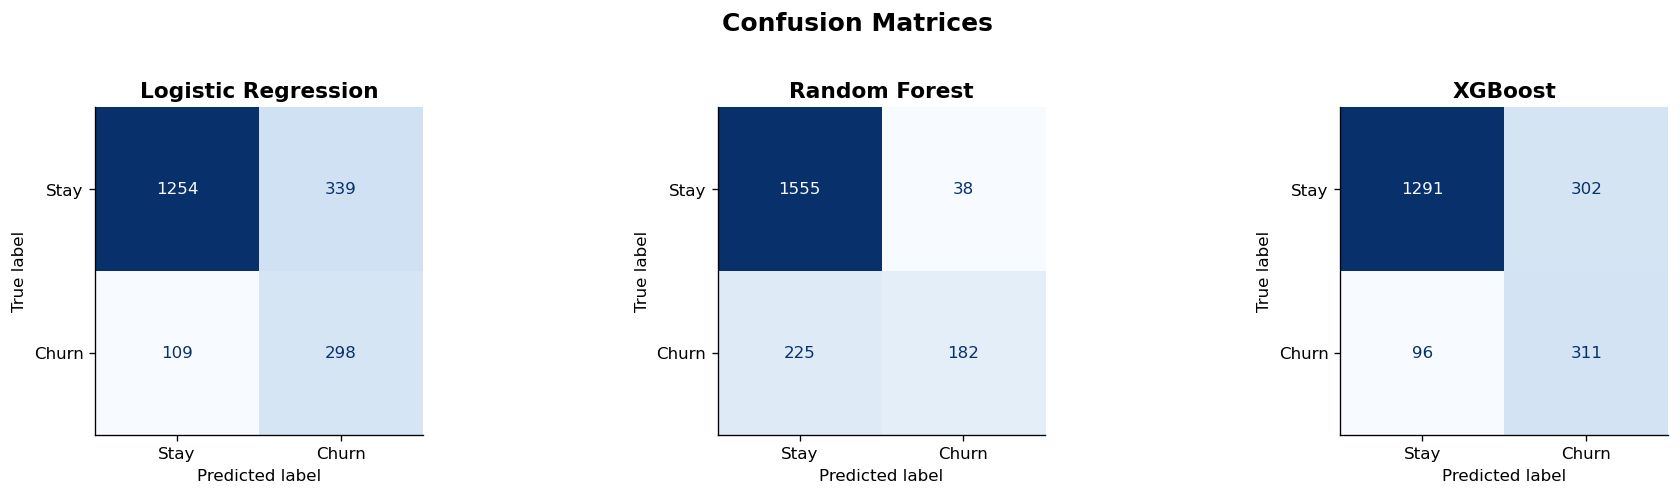

In [37]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_keys = list(results.keys())

for ax, name in zip(axes, model_keys):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

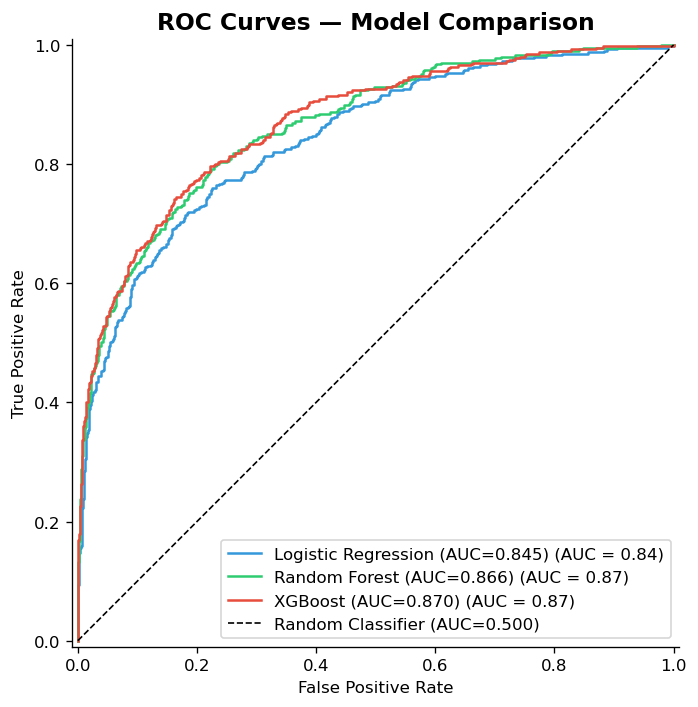

In [38]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']
estimators = [lr_gs.best_estimator_, rf_gs.best_estimator_, xgb_gs.best_estimator_]

for estimator, name, color in zip(estimators, model_keys, colors):
    RocCurveDisplay.from_estimator(
        estimator, X_test, y_test,
        name=f'{name} (AUC={results[name]["roc_auc"]:.3f})',
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC=0.500)')
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.tight_layout()
plt.show()

<a id="eight"></a>
### 8. Conclusion & Business Recommandation
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>


#### 8.1 Model Performance Summary
All models performed well, with ROC-AUC scores between 0.84 and 0.87, indicating strong ability to distinguish between churned and retained customers. Random Forest and XGBoost achieved the highest AUC (0.87), while Logistic Regression provided a solid and interpretable baseline.

However, based on F1-score and confusion matrix analysis, XGBoost performed best overall, identifying the highest number of churned customers while maintaining a good balance between precision and recall. Random Forest, although accurate, missed more churn cases, and Logistic Regression showed slightly lower performance.

#### 8.2 Business Recommandation
XGBoost is recommended as the best model for deployment due to its superior ability to detect customers at risk of churn. This makes it well-suited for targeted retention strategies, where identifying potential churners early is critical to reducing customer loss.